In [1]:
import kagglehub
path = kagglehub.dataset_download("imdevskp/corona-virus-report")

100%|██████████| 19.0M/19.0M [00:00<00:00, 106MB/s]

Extracting files...


In [2]:
import os

# List files in the downloaded directory
print(os.listdir(path))

['country_wise_latest.csv', 'covid_19_clean_complete.csv', 'full_grouped.csv', 'day_wise.csv', 'usa_county_wise.csv', 'worldometer_data.csv']


In [3]:
import pandas as pd

# Construct the full path to the desired CSV file
file_path = f"{path}/covid_19_clean_complete.csv"

# Load the dataset
df = pd.read_csv(file_path)

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
print(df.head())

# Display information about the DataFrame (columns, non-null counts, dtypes)
print("\nDataFrame Information:")
df.info()

First 5 rows of the dataset:
  Province/State Country/Region       Lat       Long        Date  Confirmed  \
0            NaN    Afghanistan  33.93911  67.709953  2020-01-22          0   
1            NaN        Albania  41.15330  20.168300  2020-01-22          0   
2            NaN        Algeria  28.03390   1.659600  2020-01-22          0   
3            NaN        Andorra  42.50630   1.521800  2020-01-22          0   
4            NaN         Angola -11.20270  17.873900  2020-01-22          0   

   Deaths  Recovered  Active             WHO Region  
0       0          0       0  Eastern Mediterranean  
1       0          0       0                 Europe  
2       0          0       0                 Africa  
3       0          0       0                 Europe  
4       0          0       0                 Africa  

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dt

In [4]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

if duplicate_rows > 0:
    print("Dropping duplicate rows.")
    df.drop_duplicates(inplace=True)
    print(f"Number of rows after dropping duplicates: {len(df)}")

# Display updated DataFrame info to confirm date conversion
print("\nDataFrame Info after Date conversion and duplicate check:")
df.info()

Number of duplicate rows: 0

DataFrame Info after Date conversion and duplicate check:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Province/State  14664 non-null  object        
 1   Country/Region  49068 non-null  object        
 2   Lat             49068 non-null  float64       
 3   Long            49068 non-null  float64       
 4   Date            49068 non-null  datetime64[ns]
 5   Confirmed       49068 non-null  int64         
 6   Deaths          49068 non-null  int64         
 7   Recovered       49068 non-null  int64         
 8   Active          49068 non-null  int64         
 9   WHO Region      49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 3.7+ MB


In [5]:
# Check unique values in 'Province/State' and 'Country/Region'
print("Unique values in 'Province/State':", df['Province/State'].nunique())
print("Unique values in 'Country/Region':", df['Country/Region'].nunique())

# Fill missing values in 'Province/State' with 'Unknown'
df['Province/State'].fillna('Unknown', inplace=True)

# Verify that there are no more missing values in 'Province/State'
print(f"\nNumber of missing values in 'Province/State' after filling: {df['Province/State'].isnull().sum()}")

# Display updated DataFrame info to confirm the change
print("\nDataFrame Info after handling missing 'Province/State' values:")
df.info()

Unique values in 'Province/State': 78
Unique values in 'Country/Region': 187

Number of missing values in 'Province/State' after filling: 0

DataFrame Info after handling missing 'Province/State' values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Province/State  49068 non-null  object        
 1   Country/Region  49068 non-null  object        
 2   Lat             49068 non-null  float64       
 3   Long            49068 non-null  float64       
 4   Date            49068 non-null  datetime64[ns]
 5   Confirmed       49068 non-null  int64         
 6   Deaths          49068 non-null  int64         
 7   Recovered       49068 non-null  int64         
 8   Active          49068 non-null  int64         
 9   WHO Region      49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memo

/tmp/ipykernel_2140/2078174214.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Province/State'].fillna('Unknown', inplace=True)


In [6]:
# Check for missing values in all columns
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
Province/State    0
Country/Region    0
Lat               0
Long              0
Date              0
Confirmed         0
Deaths            0
Recovered         0
Active            0
WHO Region        0
dtype: int64


In [7]:
# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics for Numerical Columns:")
print(df.describe())


Descriptive Statistics for Numerical Columns:
                Lat          Long                 Date     Confirmed  \
count  49068.000000  49068.000000                49068  4.906800e+04   
mean      21.433730     23.528236  2020-04-24 12:00:00  1.688490e+04   
min      -51.796300   -135.000000  2020-01-22 00:00:00  0.000000e+00   
25%        7.873054    -15.310100  2020-03-08 18:00:00  4.000000e+00   
50%       23.634500     21.745300  2020-04-24 12:00:00  1.680000e+02   
75%       41.204380     80.771797  2020-06-10 06:00:00  1.518250e+03   
max       71.706900    178.065000  2020-07-27 00:00:00  4.290259e+06   
std       24.950320     70.442740                  NaN  1.273002e+05   

              Deaths     Recovered        Active  
count   49068.000000  4.906800e+04  4.906800e+04  
mean      884.179160  7.915713e+03  8.085012e+03  
min         0.000000  0.000000e+00 -1.400000e+01  
25%         0.000000  0.000000e+00  0.000000e+00  
50%         2.000000  2.900000e+01  2.600000e+01 

In [8]:
# Check for negative 'Active' cases
negative_active_count = df[df['Active'] < 0].shape[0]
print(f"Number of rows with negative 'Active' cases: {negative_active_count}")

# Correct negative 'Active' cases by setting them to 0
if negative_active_count > 0:
    df.loc[df['Active'] < 0, 'Active'] = 0
    print("Negative 'Active' cases have been corrected to 0.")

# Verify the correction by re-checking descriptive statistics for 'Active' column
print("\nDescriptive statistics for 'Active' column after correction:")
print(df['Active'].describe())

Number of rows with negative 'Active' cases: 18
Negative 'Active' cases have been corrected to 0.

Descriptive statistics for 'Active' column after correction:
count    4.906800e+04
mean     8.085014e+03
std      7.625890e+04
min      0.000000e+00
25%      0.000000e+00
50%      2.600000e+01
75%      6.060000e+02
max      2.816444e+06
Name: Active, dtype: float64


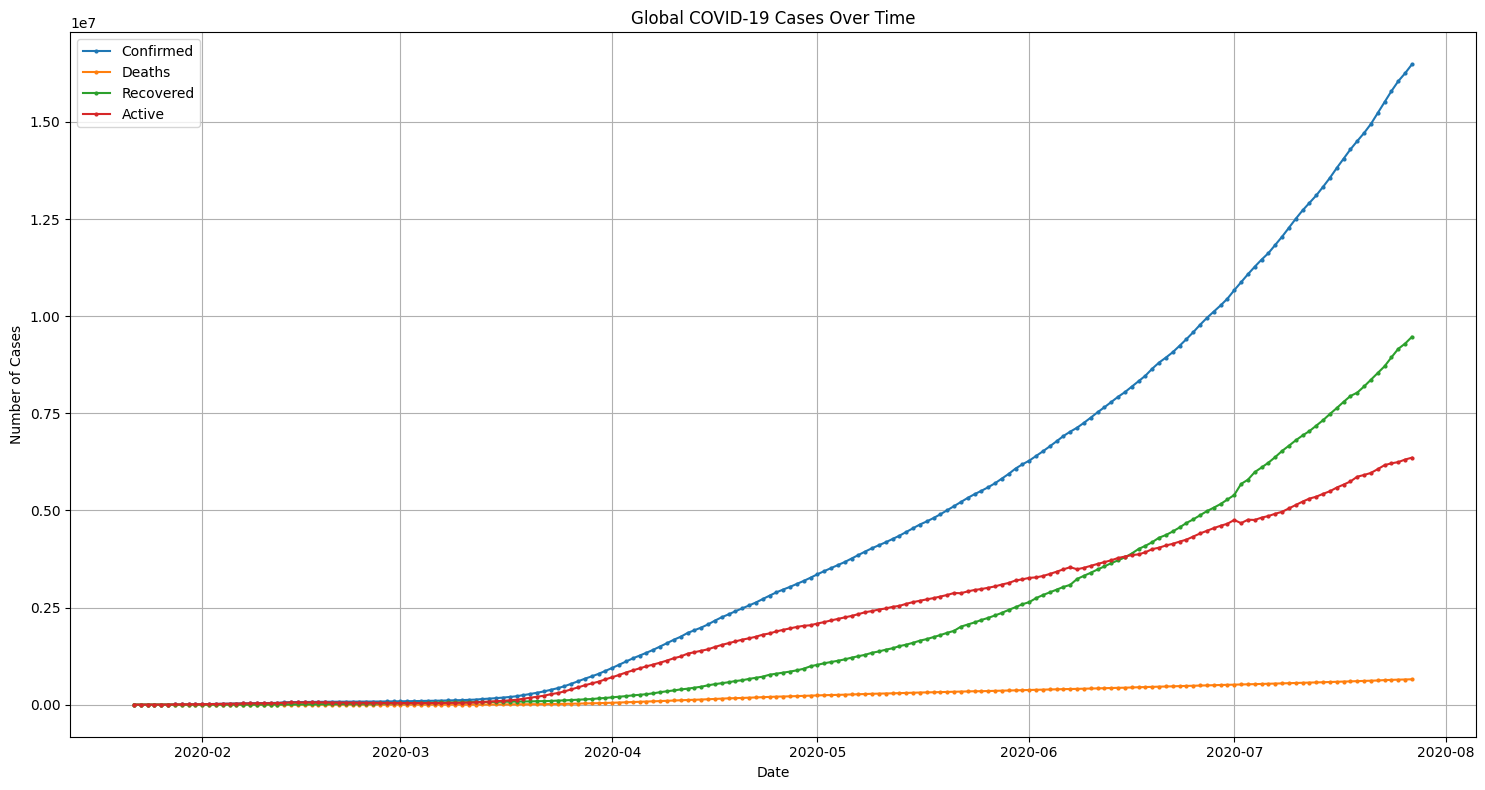

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group data by Date to get global daily totals
daily_cases = df.groupby('Date')[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum().reset_index()

# Plotting the global trends
plt.figure(figsize=(15, 8))

plt.plot(daily_cases['Date'], daily_cases['Confirmed'], label='Confirmed', marker='o', markersize=2)
plt.plot(daily_cases['Date'], daily_cases['Deaths'], label='Deaths', marker='o', markersize=2)
plt.plot(daily_cases['Date'], daily_cases['Recovered'], label='Recovered', marker='o', markersize=2)
plt.plot(daily_cases['Date'], daily_cases['Active'], label='Active', marker='o', markersize=2)

plt.title('Global COVID-19 Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Cases')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

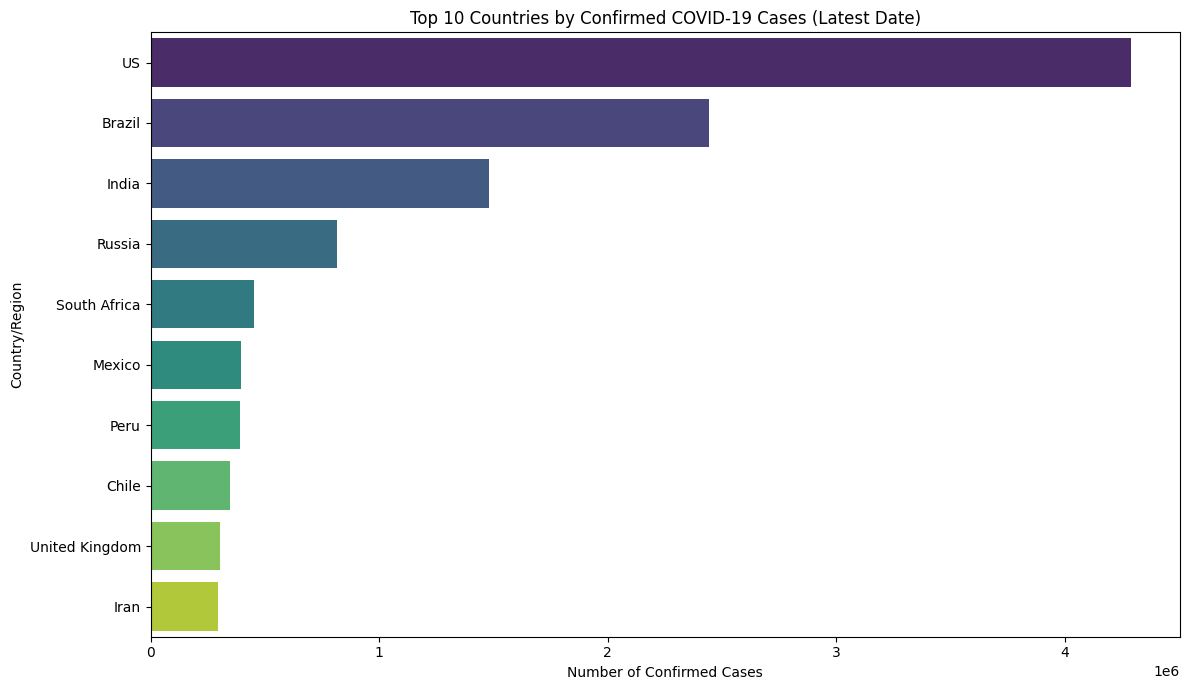

In [11]:
# Get the latest data for each country/region
latest_data = df[df['Date'] == df['Date'].max()]

# Group by Country/Region and sum the cases
country_wise = latest_data.groupby('Country/Region')[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum().reset_index()

# Sort by Confirmed cases to find top affected countries
top_10_confirmed = country_wise.sort_values('Confirmed', ascending=False).head(10)

# Plotting top 10 countries by Confirmed cases
plt.figure(figsize=(12, 7))
sns.barplot(x='Confirmed', y='Country/Region', hue='Country/Region', data=top_10_confirmed, palette='viridis', legend=False)
plt.title('Top 10 Countries by Confirmed COVID-19 Cases (Latest Date)')
plt.xlabel('Number of Confirmed Cases')
plt.ylabel('Country/Region')
plt.tight_layout()
plt.show()

In [12]:
# Calculate daily new cases (Confirmed, Deaths, Recovered)
# Sort the DataFrame by Country/Region and Date to ensure correct daily differences
df_sorted = df.sort_values(by=['Country/Region', 'Date'])

# Calculate the difference for each country individually
df_sorted['Daily_Confirmed'] = df_sorted.groupby('Country/Region')['Confirmed'].diff().fillna(0)
df_sorted['Daily_Deaths'] = df_sorted.groupby('Country/Region')['Deaths'].diff().fillna(0)
df_sorted['Daily_Recovered'] = df_sorted.groupby('Country/Region')['Recovered'].diff().fillna(0)

# Display the first few rows with the new daily columns
print("DataFrame with Daily New Cases:")
print(df_sorted[['Date', 'Country/Region', 'Confirmed', 'Daily_Confirmed', 'Deaths', 'Daily_Deaths', 'Recovered', 'Daily_Recovered']].head(10))

# Ensure daily counts are not negative (can happen due to data inconsistencies)
df_sorted['Daily_Confirmed'] = df_sorted['Daily_Confirmed'].apply(lambda x: max(0, x))
df_sorted['Daily_Deaths'] = df_sorted['Daily_Deaths'].apply(lambda x: max(0, x))
df_sorted['Daily_Recovered'] = df_sorted['Daily_Recovered'].apply(lambda x: max(0, x))

# Store the updated DataFrame back to df for subsequent operations
df = df_sorted.copy()

DataFrame with Daily New Cases:
           Date Country/Region  Confirmed  Daily_Confirmed  Deaths  \
0    2020-01-22    Afghanistan          0              0.0       0   
261  2020-01-23    Afghanistan          0              0.0       0   
522  2020-01-24    Afghanistan          0              0.0       0   
783  2020-01-25    Afghanistan          0              0.0       0   
1044 2020-01-26    Afghanistan          0              0.0       0   
1305 2020-01-27    Afghanistan          0              0.0       0   
1566 2020-01-28    Afghanistan          0              0.0       0   
1827 2020-01-29    Afghanistan          0              0.0       0   
2088 2020-01-30    Afghanistan          0              0.0       0   
2349 2020-01-31    Afghanistan          0              0.0       0   

      Daily_Deaths  Recovered  Daily_Recovered  
0              0.0          0              0.0  
261            0.0          0              0.0  
522            0.0          0              0.0  
7

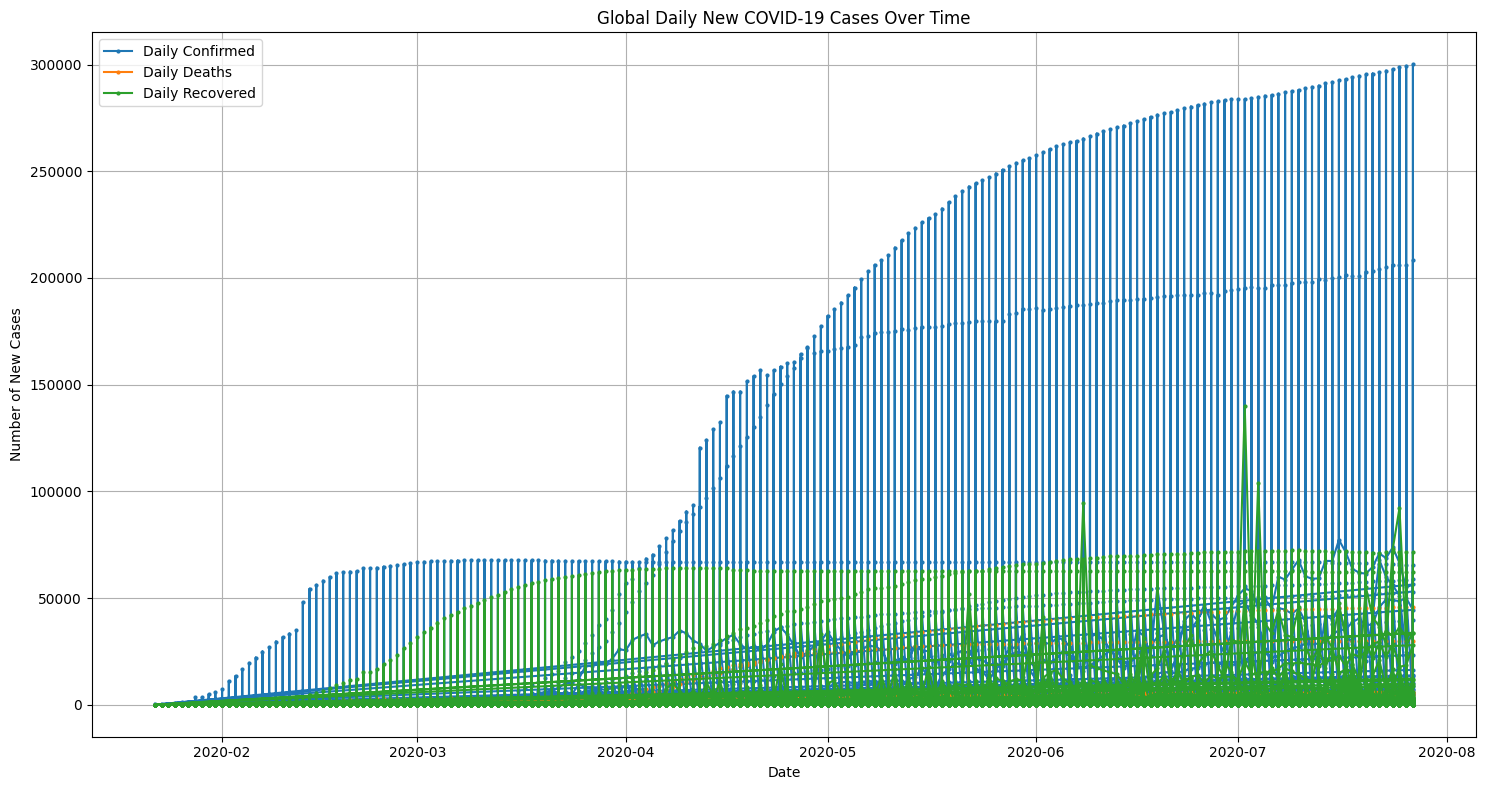

In [13]:
# Plotting daily new cases
plt.figure(figsize=(15, 8))

plt.plot(df['Date'], df['Daily_Confirmed'], label='Daily Confirmed', marker='o', markersize=2)
plt.plot(df['Date'], df['Daily_Deaths'], label='Daily Deaths', marker='o', markersize=2)
plt.plot(df['Date'], df['Daily_Recovered'], label='Daily Recovered', marker='o', markersize=2)

plt.title('Global Daily New COVID-19 Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Number of New Cases')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

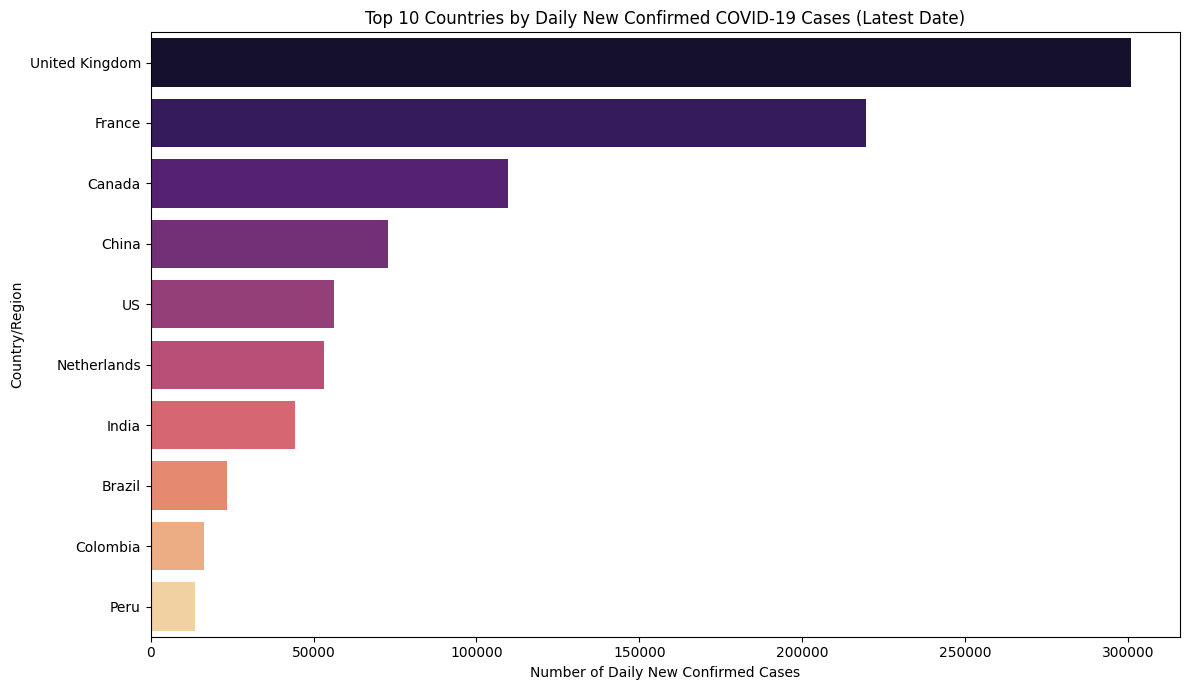

In [14]:
# Identify top 10 countries by daily new confirmed cases on the latest date
latest_daily_data = df[df['Date'] == df['Date'].max()]
top_10_daily_confirmed = latest_daily_data.groupby('Country/Region')['Daily_Confirmed'].sum().reset_index()
top_10_daily_confirmed = top_10_daily_confirmed.sort_values('Daily_Confirmed', ascending=False).head(10)

# Plotting top 10 countries by daily new confirmed cases
plt.figure(figsize=(12, 7))
sns.barplot(x='Daily_Confirmed', y='Country/Region', hue='Country/Region', data=top_10_daily_confirmed, palette='magma', legend=False)
plt.title('Top 10 Countries by Daily New Confirmed COVID-19 Cases (Latest Date)')
plt.xlabel('Number of Daily New Confirmed Cases')
plt.ylabel('Country/Region')
plt.tight_layout()
plt.show()

In [15]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Aggregate daily new cases globally
global_daily_cases = df.groupby('Date')[['Daily_Confirmed', 'Daily_Deaths', 'Daily_Recovered']].sum().reset_index()

print("Global Daily New Cases:")
print(global_daily_cases.head())

# Prepare data for time series forecasting
def create_sequences(data, look_back):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back)])
        y.append(data[i + look_back, 0]) # Assuming first column is the target (Daily_Confirmed)
    return np.array(X), np.array(y)

# Select the relevant columns for our model
dataset = global_daily_cases[['Daily_Confirmed', 'Daily_Deaths', 'Daily_Recovered']].values

# Normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
dataset_scaled = scaler.fit_transform(dataset)

# Define the look_back period (e.g., use the previous 7 days to predict the next day)
look_back = 7

# Create sequences
X, y = create_sequences(dataset_scaled, look_back)

print(f"\nShape of X (input sequences): {X.shape}")
print(f"Shape of y (target values): {y.shape}")

# Split data into training and testing sets (e.g., 80% train, 20% test)
train_size = int(len(X) * 0.8)
X_train, X_test = X[0:train_size], X[train_size:len(X)]
y_train, y_test = y[0:train_size], y[train_size:len(y)]

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Global Daily New Cases:
        Date  Daily_Confirmed  Daily_Deaths  Daily_Recovered
0 2020-01-22            518.0          17.0             28.0
1 2020-01-23            554.0          18.0             30.0
2 2020-01-24            736.0          25.0             36.0
3 2020-01-25           1037.0          41.0             39.0
4 2020-01-26           1504.0          54.0             52.0

Shape of X (input sequences): (181, 7, 3)
Shape of y (target values): (181,)
Shape of X_train: (144, 7, 3)
Shape of y_train: (144,)
Shape of X_test: (37, 7, 3)
Shape of y_test: (37,)


In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Reshape input to be 3D [samples, timesteps, features] for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Define the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(look_back, dataset_scaled.shape[1])))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1)) # Output layer for predicting one value (Daily_Confirmed)

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Display model summary
print("\nLSTM Model Summary:")
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\nModel training complete.")


LSTM Model Summary:


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 50)          │        10,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,051 (121.29 KB)

 Trainable params: 31,051 (121.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 191ms/step - loss: 0.1445 - val_loss: 0.1880
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0281 - val_loss: 3.4991e-04
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0114 - val_loss: 0.0399
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0154 - val_loss: 5.8774e-04
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0039 - val_loss: 0.0150
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0075 - val_loss: 0.0145
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0058 - val_loss: 4.9665e-04
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0030 - val_loss: 0.0057
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0038 - val_loss: 0.0047
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0029 - val_loss: 2.2548e-04
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0026 - val_loss: 8.1400e-04
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0027

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 438ms/step

Test RMSE: 58763.83


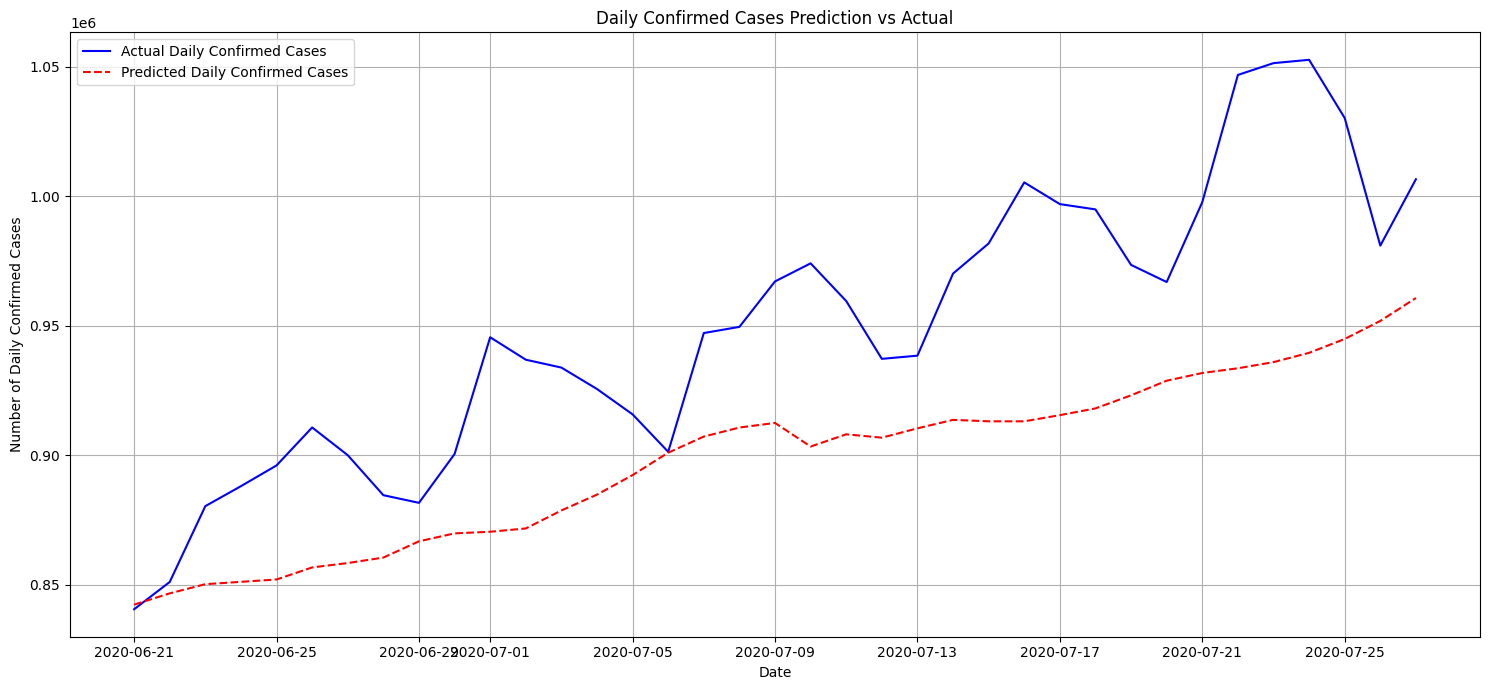

In [17]:
from sklearn.metrics import mean_squared_error

# Make predictions on the test set
y_pred = model.predict(X_test)

# Inverse transform the predictions and actual values to original scale
y_pred_inv = scaler.inverse_transform(np.concatenate((y_pred, np.zeros((len(y_pred), dataset_scaled.shape[1] - 1))), axis=1))[:,0]
y_test_inv = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros((len(y_test), dataset_scaled.shape[1] - 1))), axis=1))[:,0]

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
print(f"\nTest RMSE: {rmse:.2f}")

# Plot the results
plt.figure(figsize=(15, 7))

# Create a date range for plotting test data
dates = global_daily_cases['Date'].values
test_dates = dates[len(dates) - len(y_test) :]

plt.plot(test_dates, y_test_inv, label='Actual Daily Confirmed Cases', color='blue')
plt.plot(test_dates, y_pred_inv, label='Predicted Daily Confirmed Cases', color='red', linestyle='--')

plt.title('Daily Confirmed Cases Prediction vs Actual')
plt.xlabel('Date')
plt.ylabel('Number of Daily Confirmed Cases')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

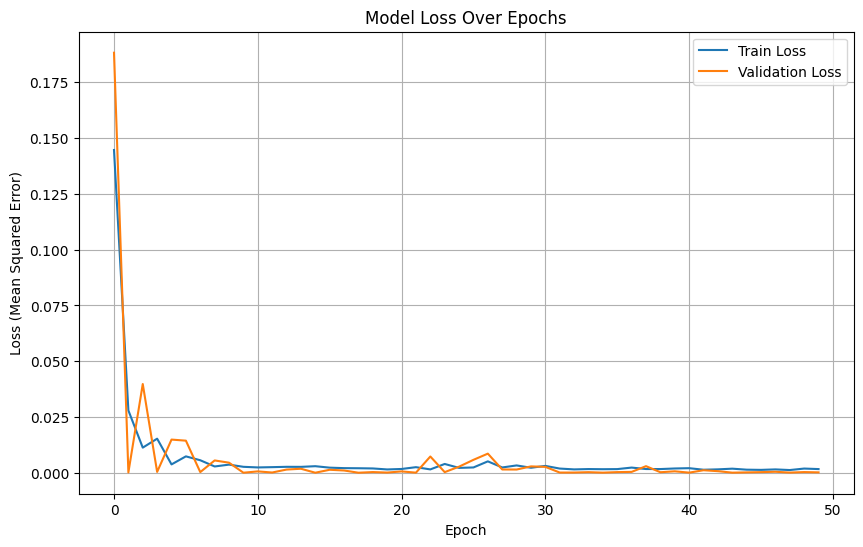

In [18]:
# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss (Mean Squared Error)')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

In [19]:
# Install Streamlit
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 81.7 MB/s eta 0:00:00


In [20]:
import joblib

# Save the trained model and scaler
model.save('lstm_model.h5')
joblib.dump(scaler, 'min_max_scaler.pkl')

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


Now that the model and scaler are saved, let's create the Streamlit app. You'll need to save the following code as a Python file (e.g., `app.py`) and run it from your terminal.

In [21]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler
import joblib

st.set_page_config(page_title="COVID-19 Case Predictor 🦠", layout="centered", initial_sidebar_state="expanded")

st.title('COVID-19 Daily Case Predictor 📊')
st.write('Enter the last 7 days of global daily confirmed, death, and recovered cases to predict the next day\'s confirmed cases.')

# Load the pre-trained model and scaler
@st.cache_resource
def load_resources():
    model = load_model('lstm_model.h5')
    scaler = joblib.load('min_max_scaler.pkl')
    return model, scaler

model, scaler = load_resources()

look_back = 7 # This should match the look_back used during training
num_features = 3 # Daily_Confirmed, Daily_Deaths, Daily_Recovered

st.sidebar.header('Input Latest 7 Days Data 👇')

user_input = np.zeros((look_back, num_features))

for i in range(look_back):
    st.sidebar.subheader(f'Day {i+1} 🗓️')
    user_input[i, 0] = st.sidebar.number_input(f'Confirmed Cases (Day {i+1})', min_value=0, value=0, key=f'conf_{i}')
    user_input[i, 1] = st.sidebar.number_input(f'Death Cases (Day {i+1})', min_value=0, value=0, key=f'deaths_{i}')
    user_input[i, 2] = st.sidebar.number_input(f'Recovered Cases (Day {i+1})', min_value=0, value=0, key=f'rec_{i}')

if st.sidebar.button('Predict Next Day 🔮'):
    # Scale the user input
    # The scaler was fitted on (Daily_Confirmed, Daily_Deaths, Daily_Recovered)
    # We need to ensure the input for prediction has the same shape as the data scaler was trained on
    # For this specific case, we're predicting 'Daily_Confirmed' (index 0) of the next day.
    # The scaler expects all 3 features.

    # Create a dummy array with a similar structure to what the scaler expects (including the target feature)
    # The actual values for daily deaths and recovered from the user input for the current day will be scaled appropriately.

    # We need to ensure that the input to the scaler has the correct number of columns (3 in this case)
    # Since the user_input already has 3 columns, we can directly scale it.

    scaled_input = scaler.transform(user_input)

    # Reshape for LSTM prediction
    scaled_input = scaled_input.reshape(1, look_back, num_features)

    # Make prediction
    predicted_scaled = model.predict(scaled_input)

    # Inverse transform the prediction
    # Create a dummy array with the same number of features as the original dataset_scaled
    # Only the first feature (Daily_Confirmed) of the prediction is valid.
    # The other features for inverse_transform will be zeros or other placeholder values
    # that don't affect the inverse transformation of the first feature.
    dummy_row = np.zeros((1, num_features))
    dummy_row[0, 0] = predicted_scaled[0, 0] # Place the predicted confirmed value

    predicted_original = scaler.inverse_transform(dummy_row)[:, 0]

    st.success(f'Predicted Daily Confirmed Cases for Next Day: **{int(predicted_original[0]):,}** 📈')
    st.balloons()

st.sidebar.markdown('---')
st.sidebar.info('✨ Made with Streamlit by your friendly AI assistant!')

Writing app.py


To run this Streamlit application:

1.  **Open a terminal** in your Colab environment.
2.  **Navigate to the directory** where `app.py` was saved (it's usually `/content/` by default).
3.  **Execute the command:**
    ```bash
    streamlit run app.py
    ```

Streamlit will then provide a local URL and an external URL. Click on the external URL to interact with your application in a new browser tab. 🌐

In [22]:
!pip install --ignore-installed blinker
!pip install streamlit

In [23]:
!pip install streamlit pyngrok

In [24]:
from pyngrok import ngrok
ngrok.set_auth_token("3H2nxZtP4iC5L9tX9K97OPLut9W_4JsZrRVF5aRFQpQCCePy1")

In [25]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://vanity-amperage-commodore.ngrok-free.dev" -> "http://localhost:8501"


In [26]:
# Run the Streamlit app
# This will provide a public URL to access the app
!streamlit run app.py &




2026-09-01 16:48:50.627 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.182.47.21:8501

2026-09-01 16:48:59.825344: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step


  Stopping...
